# Visualization Suite — Slide-Ready, with Best-Condition Highlighting

Same data, statistics and "best condition" rules as before; the figures are redesigned for 16:9 slides and saved to `slides_suite/` as PNG (300 dpi) + SVG (editable text).

| File | Content |
|---|---|
| `S01_best_conditions` | Summary matrix: best edited condition per AOI × metric, with its d_z and 95% CI |
| `S02_effect_profiles` | All AOIs side by side, one shared x-axis |
| `S03a–c_effects_<AOI>` | One effect-profile slide per AOI (larger) |
| `S04_raincloud_<AOI>_1/2` | Rainclouds, 4 metrics per slide (two slides per AOI) |

### What changed vs. the previous version
- **One colour per condition everywhere** (before, B was orange in the rainclouds but blue in the effect plot). A = original is neutral grey.
- **Stars are visible**: the "best" label box used to sit on top of the star and hide it.
- **Effect profiles share one x-axis**, so a d_z of 1.0 looks the same size in every AOI.
- **Stars are honest**: a filled ★ means the 95% CI excludes 0; a hollow ☆ means it is only the best point estimate.
- The shaded column is now a setting (`HIGHLIGHT_CONDITION`, was hard-coded to C).
- The bootstrap is vectorised; it uses the same random draws, so the numbers are identical, just faster.

Edit `BEST_RULES` to change what counts as "best".

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

from scipy import stats
from scipy.stats import gaussian_kde

## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]
EDITED = ["B", "C", "D", "E"]           # compared against A (original)
AOIS = ["CTA", "Headline", "Product"]

METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

# ---------------------------------------------------------
# IMPORTANT: define how "best" is chosen for each metric
# ---------------------------------------------------------
BEST_RULES = {
    "VAI (%)": "max",
    "TTFF (s)": "min",
    "Time spent (s)": "max",
    "Fixations": "max",
    "Fix. duration (s)": "min",
    "FFD (s)": "min",
    "K-coefficient": "max",
    "Revisits": "max",
}

RANDOM_SEED = 42
N_BOOTSTRAP = 5000

# ---------- slide settings ----------
SLIDE_DIR = Path("slides_suite")
SLIDE_SIZE = (13.333, 7.5)          # standard 16:9
SLIDE_DPI = 300
EXPORT_SVG = True
METRICS_PER_RAIN_SLIDE = 4          # 4 -> two raincloud slides per AOI
HIGHLIGHT_CONDITION = "C"           # shaded column in rainclouds; None to disable
MAKE_PER_AOI_EFFECT_SLIDES = True

CONDITION_COLORS = {                # same colours on every slide
    "A": "#6B7280",   # original = neutral grey
    "B": "#2F6FDB",
    "C": "#E07B18",
    "D": "#2E9E6B",
    "E": "#8B5CF6",
}
CONDITION_NOTE = "A = original ad · B–E = edited versions"

## 2. Load data

In [3]:
if not Path(LONG_CSV).exists():
    raise FileNotFoundError(f"Could not find {LONG_CSV}")

df = pd.read_csv(LONG_CSV)
df.columns = [str(c).replace("**", "").strip() for c in df.columns]

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

print("Rows:", len(df))
print("AOIs:", sorted(df["AOI"].unique()))
print("Metrics:", sorted(df["metric"].unique()))


Rows: 2320
AOIs: ['CTA', 'Headline', 'Product']
Metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']


## 3. Shared helpers (statistics unchanged)

In [4]:
def get_focus(aoi, metric):
    return df[
        (df["AOI"] == aoi)
        & (df["metric"] == metric)
        & (df["condition"].isin(CONDITION_ORDER))
    ].copy()


def get_summary(focus):
    rows = []

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[focus["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .values
        )

        n = len(vals)

        if n == 0:
            rows.append({
                "condition": cond,
                "n": 0,
                "mean": np.nan,
                "ci95": np.nan,
                "lower": np.nan,
                "upper": np.nan,
            })
            continue

        mean = np.mean(vals)

        if n > 1:
            sd = np.std(vals, ddof=1)
            se = sd / np.sqrt(n)
            ci = stats.t.ppf(0.975, n - 1) * se
        else:
            ci = np.nan

        rows.append({
            "condition": cond,
            "n": n,
            "mean": mean,
            "ci95": ci,
            "lower": mean - ci if np.isfinite(ci) else np.nan,
            "upper": mean + ci if np.isfinite(ci) else np.nan,
        })

    return pd.DataFrame(rows)


def get_pivot(focus):
    return (
        focus.pivot(index="Img", columns="condition", values="value")
        .reindex(columns=CONDITION_ORDER)
    )


def paired_dz(x, y):
    d = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    d = d[np.isfinite(d)]

    if len(d) < 2:
        return np.nan

    sd = np.std(d, ddof=1)

    if sd == 0:
        return 0.0

    return np.mean(d) / sd


def bootstrap_dz(x, y, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    """Percentile bootstrap CI for paired d_z.
    Vectorised, but draws the same resamples in the same order as the
    original loop, so results are identical."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan

    obs = paired_dz(x, y)

    rng = np.random.default_rng(seed)
    d = y - x
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    resampled = d[idx]
    sd = resampled.std(axis=1, ddof=1)
    boot = np.divide(resampled.mean(axis=1), sd,
                     out=np.zeros(n_boot), where=sd != 0)
    boot = boot[np.isfinite(boot)]

    if len(boot) == 0:
        return obs, np.nan, np.nan

    lo, hi = np.percentile(boot, [2.5, 97.5])

    return obs, lo, hi


def get_best_condition(summary, metric):
    """
    Returns the best condition based on the rule in BEST_RULES.
    """
    rule = BEST_RULES.get(metric, "max")

    tmp = summary[["condition", "mean"]].dropna().copy()

    if len(tmp) == 0:
        return None

    if rule == "min":
        idx = tmp["mean"].idxmin()
    else:
        idx = tmp["mean"].idxmax()

    return tmp.loc[idx, "condition"]


def get_best_profile_condition(sub_effects, metric):
    """
    In the effect-profile figure, choose the best among B/C/D/E
    according to the metric direction.
    """
    rule = BEST_RULES.get(metric, "max")
    tmp = sub_effects[sub_effects["metric"] == metric].dropna(subset=["dz"]).copy()

    if len(tmp) == 0:
        return None

    if rule == "min":
        # Lower than A is better -> more negative dz is better
        idx = tmp["dz"].idxmin()
    else:
        # Higher than A is better -> more positive dz is better
        idx = tmp["dz"].idxmax()

    return tmp.loc[idx, "condition"]


## 4. Effect sizes vs A (paired d_z + bootstrap 95% CI)

In [5]:
effect_rows = []
seed_counter = 0

for aoi in AOIS:
    for metric in METRICS:
        focus = get_focus(aoi, metric)
        pivot = get_pivot(focus)

        if "A" not in pivot.columns:
            continue

        for cond in EDITED:
            pair = pivot[["A", cond]].dropna()

            if len(pair) < 3:
                continue

            dz, lo, hi = bootstrap_dz(
                pair["A"].values,
                pair[cond].values,
                n_boot=N_BOOTSTRAP,
                seed=RANDOM_SEED + seed_counter
            )

            seed_counter += 1

            effect_rows.append({
                "AOI": aoi,
                "metric": metric,
                "condition": cond,
                "n": len(pair),
                "dz": dz,
                "ci_lower": lo,
                "ci_upper": hi,
            })

effects = pd.DataFrame(effect_rows)
effects.head()


effects["ci_excludes_0"] = (effects["ci_lower"] > 0) | (effects["ci_upper"] < 0)

# best edited condition per AOI × metric (same rule as before)
best_rows = []
for aoi in AOIS:
    sub = effects[effects["AOI"] == aoi]
    for metric in METRICS:
        cond = get_best_profile_condition(sub, metric)
        if cond is None:
            continue
        r = sub[(sub["metric"] == metric) & (sub["condition"] == cond)].iloc[0]
        best_rows.append({**r.to_dict(), "rule": BEST_RULES.get(metric, "max")})
best = pd.DataFrame(best_rows)

print(f"{len(effects)} effects computed")
effects.head()

96 effects computed


,AOI,metric,condition,n,dz,ci_lower,ci_upper,ci_excludes_0
0,CTA,VAI (%),B,20,0.554590,0.134669,1.200406,True
1,CTA,VAI (%),C,20,0.878400,0.471059,1.503934,True
2,CTA,VAI (%),D,19,0.436254,-0.013013,1.320612,False
3,CTA,VAI (%),E,18,0.436764,-0.001279,1.098197,False
4,CTA,TTFF (s),B,18,-0.486774,-1.224384,-0.020155,True


## 5. Slide style and helpers

In [6]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.titlesize": 17,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
})

TEXT, MUTED, GRID = "#1F2937", "#6B7280", "#E5E7EB"
OFFSETS = dict(zip(EDITED, np.linspace(-0.27, 0.27, len(EDITED))))


def tint(color, amount=0.85):
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


def short_metric(m):
    return re.sub(r"\s*\(.*?\)", "", str(m))


def add_title(fig, title, subtitle=None):
    fig.text(0.035, 0.955, title, fontsize=27, fontweight="bold", color=TEXT, va="top")
    if subtitle:
        fig.text(0.035, 0.885, subtitle, fontsize=16, color=MUTED, va="top")


def add_footnote(fig, text):
    fig.text(0.035, 0.018, text, fontsize=11, color=MUTED, va="bottom", linespacing=1.5)


def condition_legend(fig, conds, y=0.06, x=0.035, title=None):
    handles = [Line2D([0], [0], marker="o", linestyle="", markersize=11,
                      markerfacecolor=CONDITION_COLORS[c],
                      markeredgecolor="white", label=c) for c in conds]
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(x, y),
               ncol=len(conds), frameon=False, fontsize=14, title=title,
               title_fontsize=13, handletextpad=0.3, columnspacing=1.4,
               alignment="left")


def star_legend(fig, x, y):
    fig.text(x, y, "★", fontsize=18, color=TEXT, va="center")
    fig.text(x + 0.018, y, "best, 95% CI excludes 0", fontsize=13, color=TEXT, va="center")
    fig.text(x + 0.21, y, "☆", fontsize=18, color=TEXT, va="center")
    fig.text(x + 0.228, y, "best estimate, CI includes 0", fontsize=13, color=MUTED, va="center")


def style_axis(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color("#9CA3AF")
    ax.spines["bottom"].set_color("#9CA3AF")
    ax.tick_params(length=0, colors=MUTED)


def save_slide(fig, name):
    SLIDE_DIR.mkdir(exist_ok=True)
    png = SLIDE_DIR / f"{name}.png"
    fig.savefig(png, dpi=SLIDE_DPI, facecolor="white")   # exact 16:9, no tight crop
    if EXPORT_SVG:
        fig.savefig(SLIDE_DIR / f"{name}.svg", facecolor="white")
    plt.show()
    print(f"Saved: {png}" + (" (+ .svg)" if EXPORT_SVG else ""))


def draw_star(ax, x, y, color, solid=True, size=22, **kw):
    ax.text(x, y, "★" if solid else "☆", ha="center", va="center",
            fontsize=size, color=color, zorder=12, clip_on=False,
            path_effects=[pe.Stroke(linewidth=3, foreground="white"), pe.Normal()], **kw)


# symmetric x-limit shared by every effect-profile panel
XLIM = np.ceil(max(effects["ci_upper"].abs().max(), effects["ci_lower"].abs().max()) * 1.05 * 2) / 2

## 6. Slide S01 — Best condition per AOI × metric

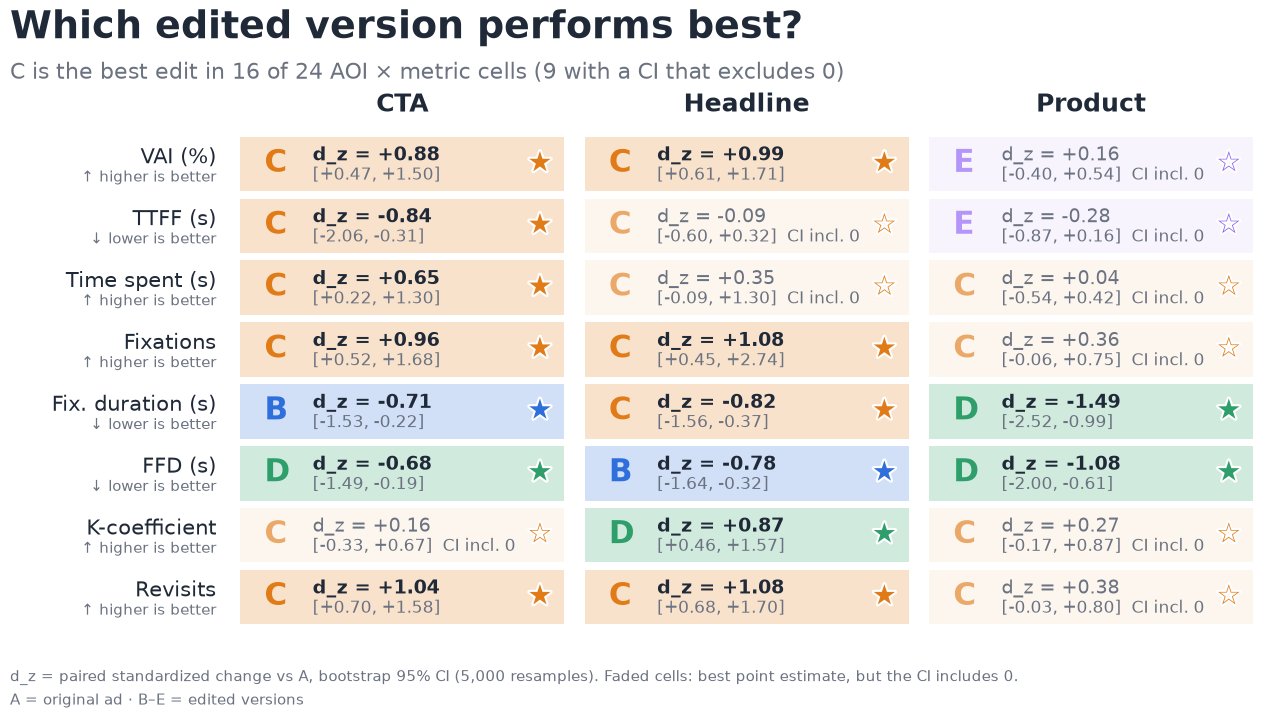

Saved: slides_suite\S01_best_conditions.png (+ .svg)


In [7]:
fig = plt.figure(figsize=SLIDE_SIZE)
counts = best["condition"].value_counts()
reliable = best[best["ci_excludes_0"]]["condition"].value_counts()
lead = counts.index[0]
add_title(fig, "Which edited version performs best?",
          f"{lead} is the best edit in {counts[lead]} of {len(best)} AOI × metric cells "
          f"({reliable.get(lead, 0)} with a CI that excludes 0)")

ax = fig.add_axes([0.2, 0.13, 0.775, 0.66])
n_rows, n_cols = len(METRICS), len(AOIS)
ax.set_xlim(0, n_cols); ax.set_ylim(n_rows, 0); ax.axis("off")

for j, aoi in enumerate(AOIS):
    ax.text(j + 0.5, -0.25, aoi, ha="center", va="bottom", fontsize=18,
            fontweight="bold", color=TEXT)

for i, metric in enumerate(METRICS):
    arrow = "↓ lower is better" if BEST_RULES.get(metric) == "min" else "↑ higher is better"
    ax.text(-0.04, i + 0.4, metric, ha="right", va="center", fontsize=15,
            color=TEXT, transform=ax.transData)
    ax.text(-0.04, i + 0.72, arrow, ha="right", va="center", fontsize=11,
            color=MUTED, transform=ax.transData)
    for j, aoi in enumerate(AOIS):
        r = best[(best["AOI"] == aoi) & (best["metric"] == metric)]
        if r.empty:
            continue
        r = r.iloc[0]
        c = CONDITION_COLORS[r["condition"]]
        ok = bool(r["ci_excludes_0"])
        ax.add_patch(plt.Rectangle((j + 0.03, i + 0.06), 0.94, 0.88,
                                   facecolor=tint(c, 0.78 if ok else 0.93),
                                   edgecolor="white", lw=0))
        ax.text(j + 0.1, i + 0.5, r["condition"], ha="left", va="center",
                fontsize=22, fontweight="bold", color=c if ok else tint(c, 0.35))
        ax.text(j + 0.24, i + 0.36, f"d_z = {r['dz']:+.2f}", ha="left", va="center",
                fontsize=14, fontweight="bold" if ok else "normal",
                color=TEXT if ok else MUTED)
        ax.text(j + 0.24, i + 0.68,
                f"[{r['ci_lower']:+.2f}, {r['ci_upper']:+.2f}]" + ("" if ok else "  CI incl. 0"),
                ha="left", va="center", fontsize=12, color=MUTED)
        draw_star(ax, j + 0.9, i + 0.5, c, solid=ok, size=20)

add_footnote(fig, f"d_z = paired standardized change vs A, bootstrap 95% CI ({N_BOOTSTRAP:,} resamples). "
                  f"Faded cells: best point estimate, but the CI includes 0.\n{CONDITION_NOTE}")
save_slide(fig, "S01_best_conditions")

## 7. Slides S02–S03 — Effect profiles (shared x-axis)

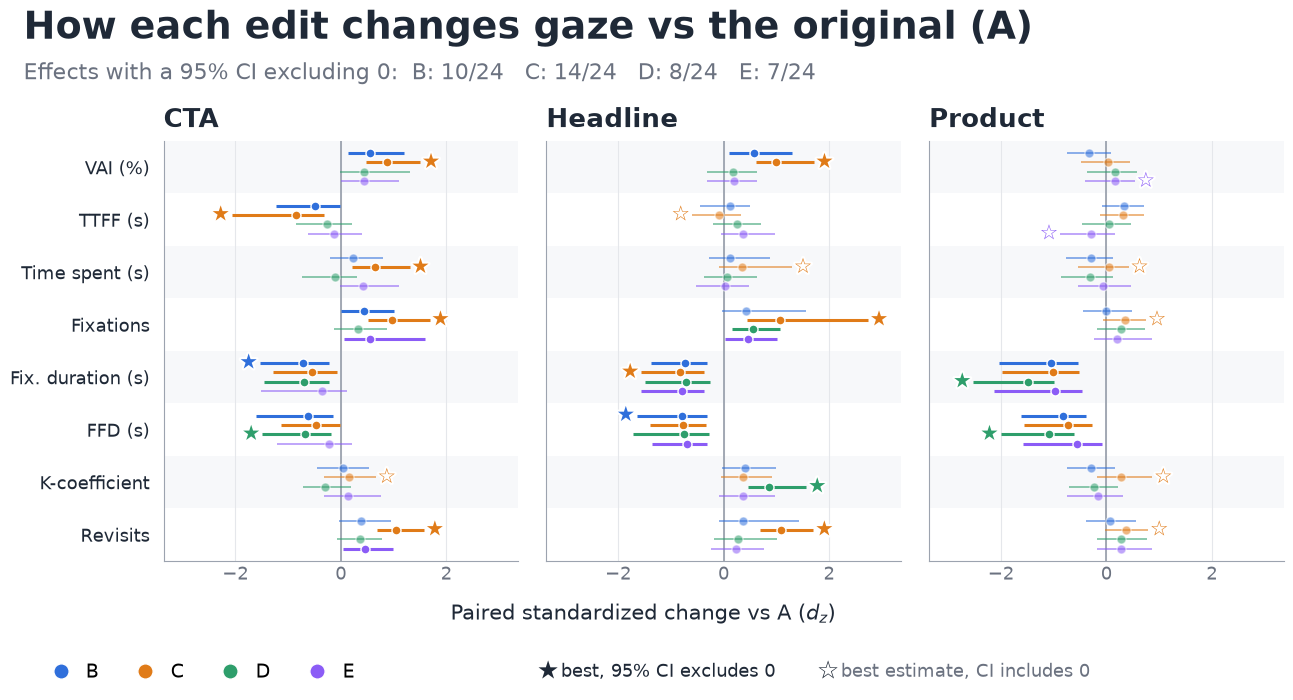

Saved: slides_suite\S02_effect_profiles.png (+ .svg)


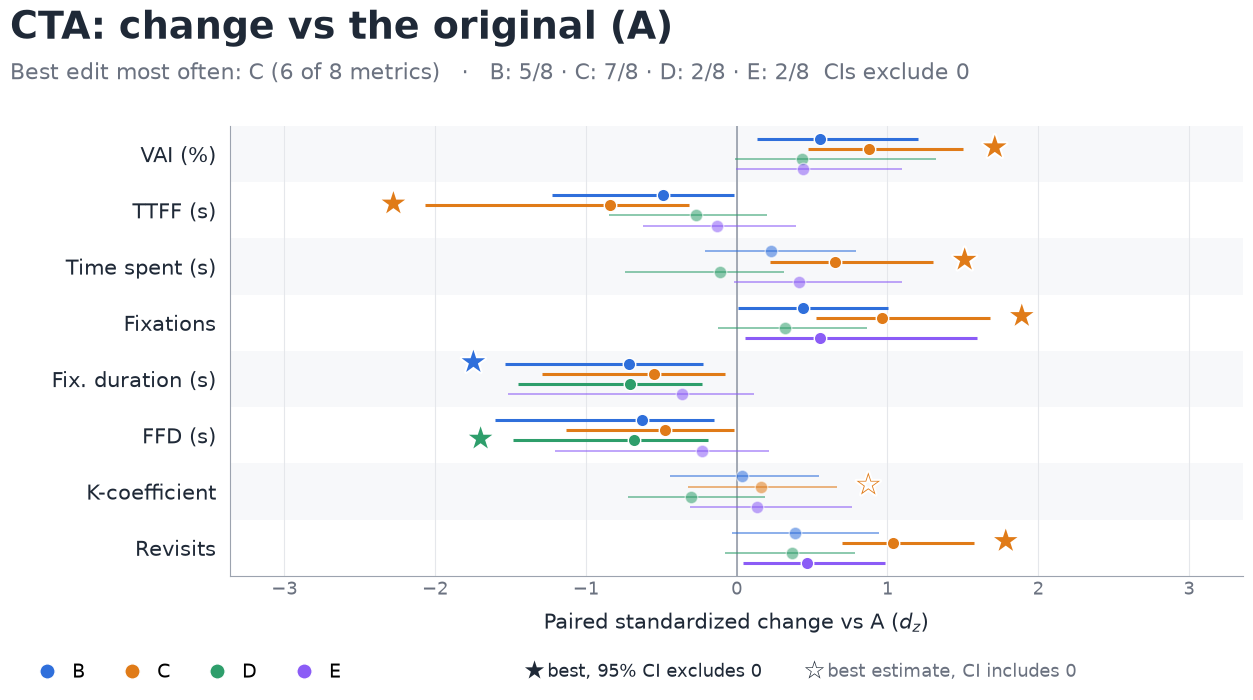

Saved: slides_suite\S03a_effects_CTA.png (+ .svg)


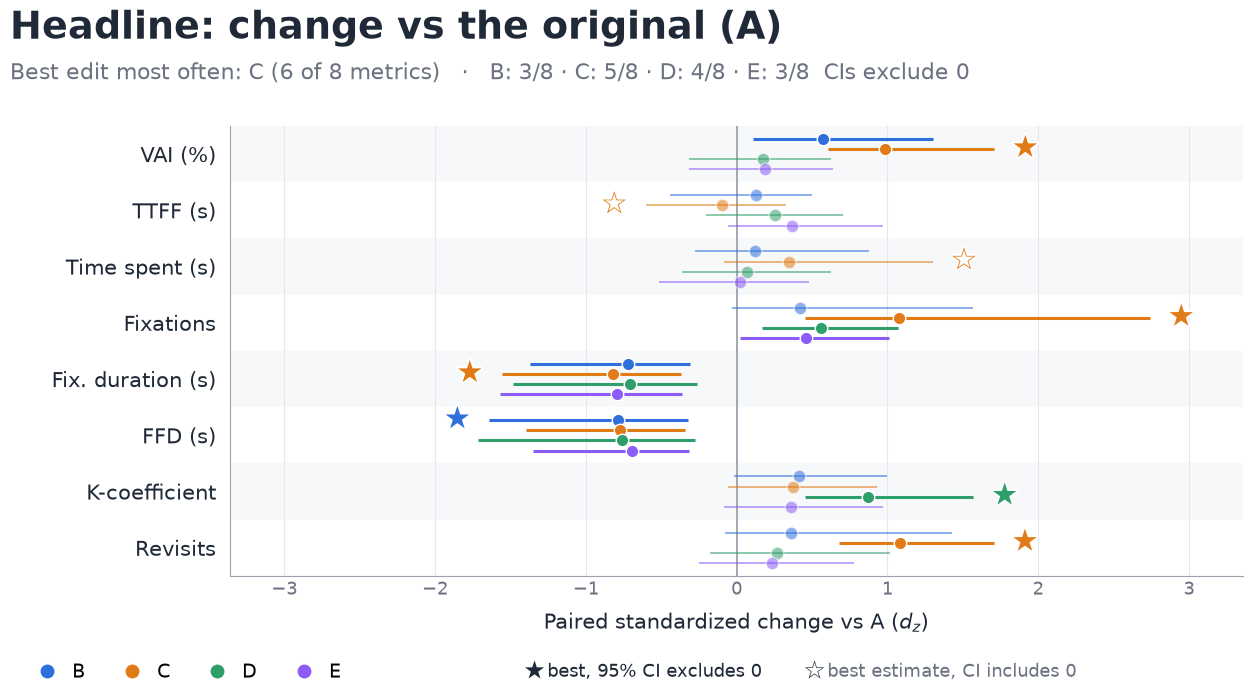

Saved: slides_suite\S03b_effects_Headline.png (+ .svg)


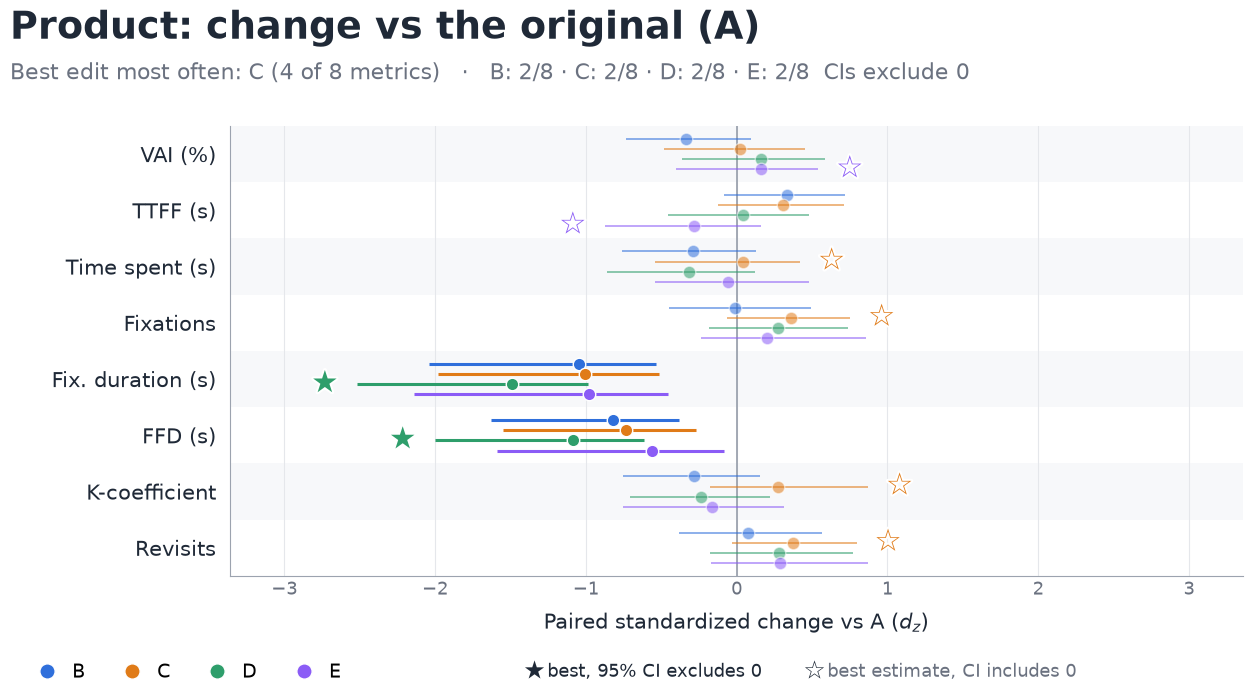

Saved: slides_suite\S03c_effects_Product.png (+ .svg)


In [8]:
def draw_effect_panel(ax, aoi, marker_size=8, star_size=20):
    sub = effects[effects["AOI"] == aoi]
    ax.axvspan(-XLIM, XLIM, color="white", zorder=0)
    ax.axvline(0, color="#9CA3AF", lw=1.3, zorder=1)
    for i in range(len(METRICS)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="#F7F8FA", zorder=0, lw=0)

    for cond in EDITED:
        csub = sub[sub["condition"] == cond]
        for i, metric in enumerate(METRICS):
            r = csub[csub["metric"] == metric]
            if r.empty:
                continue
            r = r.iloc[0]
            y = i + OFFSETS[cond]
            ok = bool(r["ci_excludes_0"])
            ax.errorbar(r["dz"], y,
                        xerr=[[r["dz"] - r["ci_lower"]], [r["ci_upper"] - r["dz"]]],
                        fmt="o", markersize=marker_size, capsize=0,
                        elinewidth=2.2 if ok else 1.4, alpha=1 if ok else 0.55,
                        color=CONDITION_COLORS[cond], markeredgecolor="white",
                        markeredgewidth=1, zorder=3)

    for i, metric in enumerate(METRICS):
        b = best[(best["AOI"] == aoi) & (best["metric"] == metric)]
        if b.empty:
            continue
        b = b.iloc[0]
        # star sits just outside the CI, on the "better" side
        x = b["ci_upper"] + XLIM * 0.07 if b["dz"] >= 0 else b["ci_lower"] - XLIM * 0.07
        draw_star(ax, x, i + OFFSETS[b["condition"]], CONDITION_COLORS[b["condition"]],
                  solid=bool(b["ci_excludes_0"]), size=star_size)

    ax.set_xlim(-XLIM * 1.12, XLIM * 1.12)            # room for stars
    ax.set_ylim(len(METRICS) - 0.5, -0.5)
    ax.set_yticks(np.arange(len(METRICS)))
    ax.set_yticklabels(METRICS)
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    style_axis(ax)
    ax.tick_params(axis="y", labelcolor=TEXT)
    ax.tick_params(axis="y", pad=10)


def effect_subtitle(sub):
    n = sub.groupby("condition")["ci_excludes_0"].sum().reindex(EDITED).fillna(0).astype(int)
    total = sub.groupby("condition").size().reindex(EDITED).fillna(0).astype(int)
    return "Effects with a 95% CI excluding 0:  " + "   ".join(
        f"{c}: {n[c]}/{total[c]}" for c in EDITED)


# ---- S02: overview ----
fig, axes = plt.subplots(1, len(AOIS), figsize=SLIDE_SIZE, sharex=True, sharey=True)
fig.subplots_adjust(left=0.14, right=0.98, top=0.78, bottom=0.22, wspace=0.08)
for k, (ax, aoi) in enumerate(zip(axes, AOIS)):
    draw_effect_panel(ax, aoi, marker_size=6.5, star_size=15)
    ax.set_title(aoi, loc="left", fontsize=19, fontweight="bold", color=TEXT, pad=10)
    if k:
        ax.tick_params(axis="y", labelleft=False)
fig.supxlabel(r"Paired standardized change vs A ($d_z$)", fontsize=15, color=TEXT, y=0.135)
add_title(fig, "How each edit changes gaze vs the original (A)", effect_subtitle(effects))
condition_legend(fig, EDITED, y=0.035)
star_legend(fig, 0.42, 0.072)
save_slide(fig, "S02_effect_profiles")

# ---- S03: one slide per AOI ----
if MAKE_PER_AOI_EFFECT_SLIDES:
    for idx, aoi in enumerate(AOIS):
        fig, ax = plt.subplots(figsize=SLIDE_SIZE)
        fig.subplots_adjust(left=0.2, right=0.96, top=0.8, bottom=0.2)
        draw_effect_panel(ax, aoi, marker_size=9, star_size=22)
        ax.set_xlabel(r"Paired standardized change vs A ($d_z$)", fontsize=15,
                      color=TEXT, labelpad=10)
        ax.tick_params(axis="y", labelsize=15)
        sub_best = best[best["AOI"] == aoi]
        top_cond = sub_best["condition"].value_counts()
        add_title(fig, f"{aoi}: change vs the original (A)",
                  f"Best edit most often: {top_cond.index[0]} ({top_cond.iloc[0]} of {len(sub_best)} metrics)   ·   "
                  + effect_subtitle(effects[effects["AOI"] == aoi]).split(":  ")[1].replace("   ", " · ")
                  + "  CIs exclude 0")
        condition_legend(fig, EDITED, y=0.035)
        star_legend(fig, 0.42, 0.072)
        save_slide(fig, f"S03{'abcdefgh'[idx]}_effects_{aoi}")

## 8. Slides S04 — Rainclouds (4 metrics per slide)

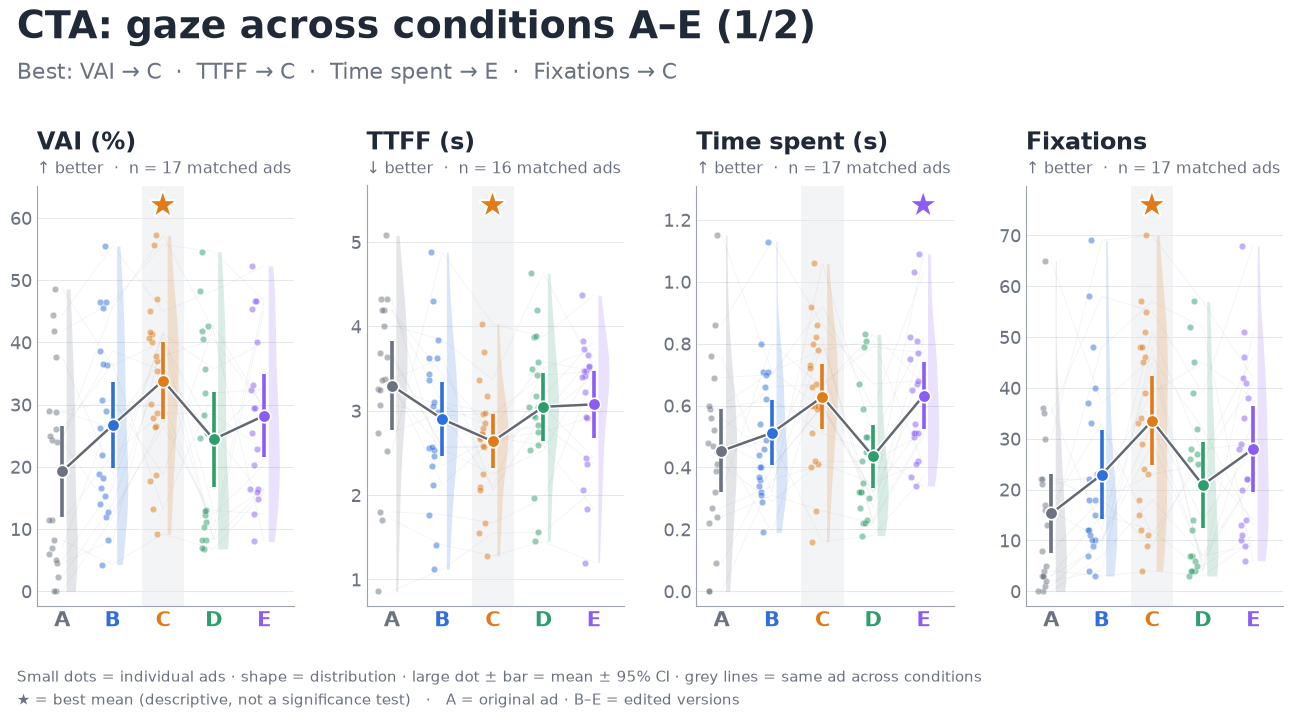

Saved: slides_suite\S04_raincloud_CTA_1.png (+ .svg)


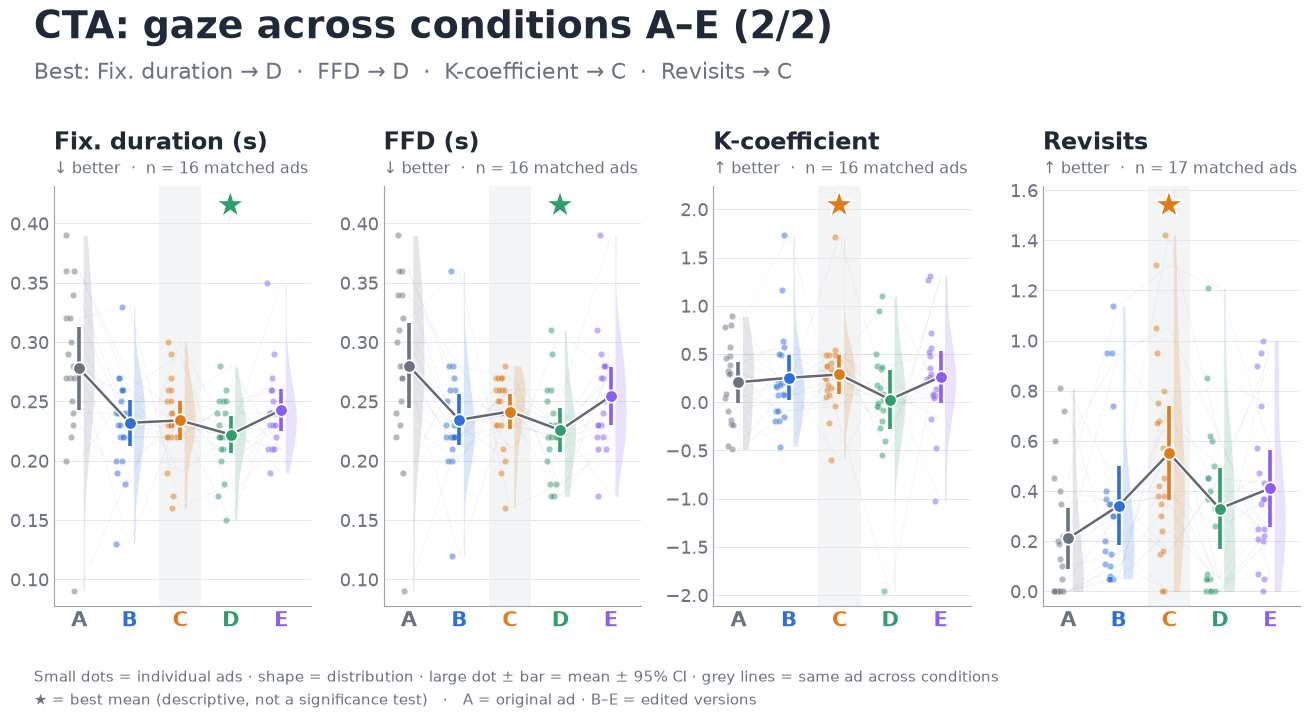

Saved: slides_suite\S04_raincloud_CTA_2.png (+ .svg)


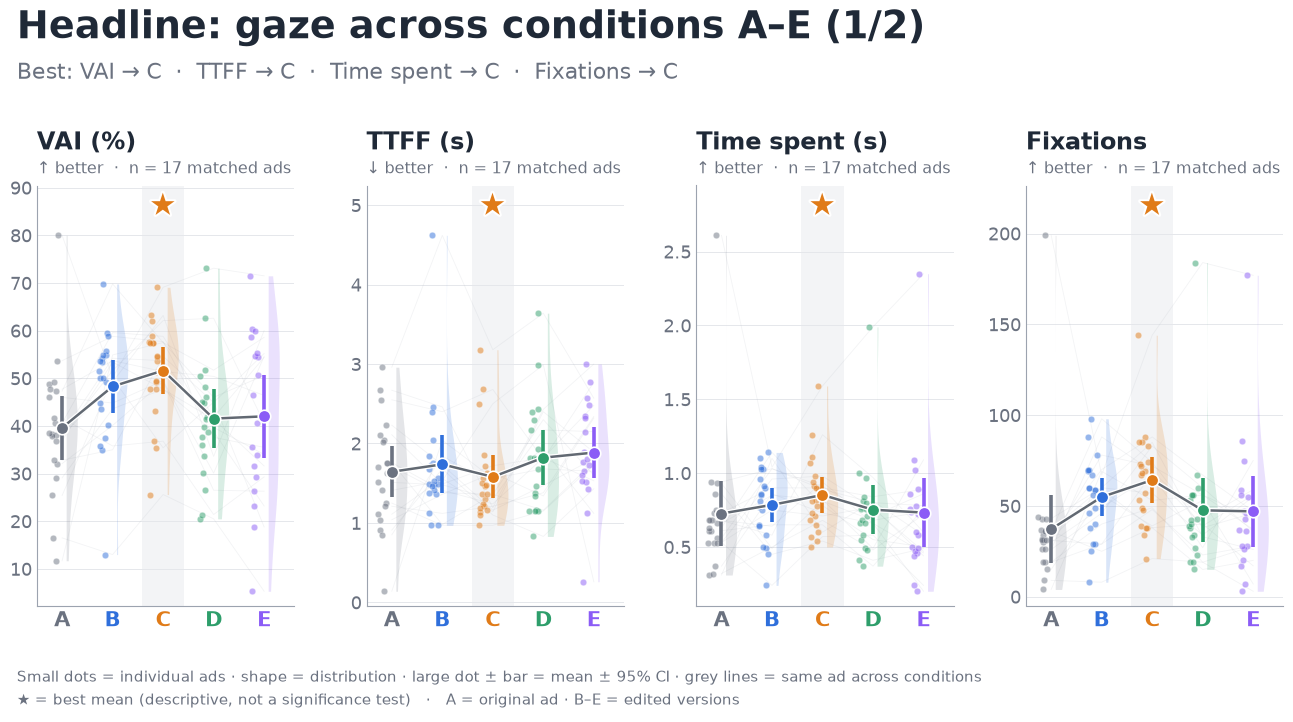

Saved: slides_suite\S04_raincloud_Headline_1.png (+ .svg)


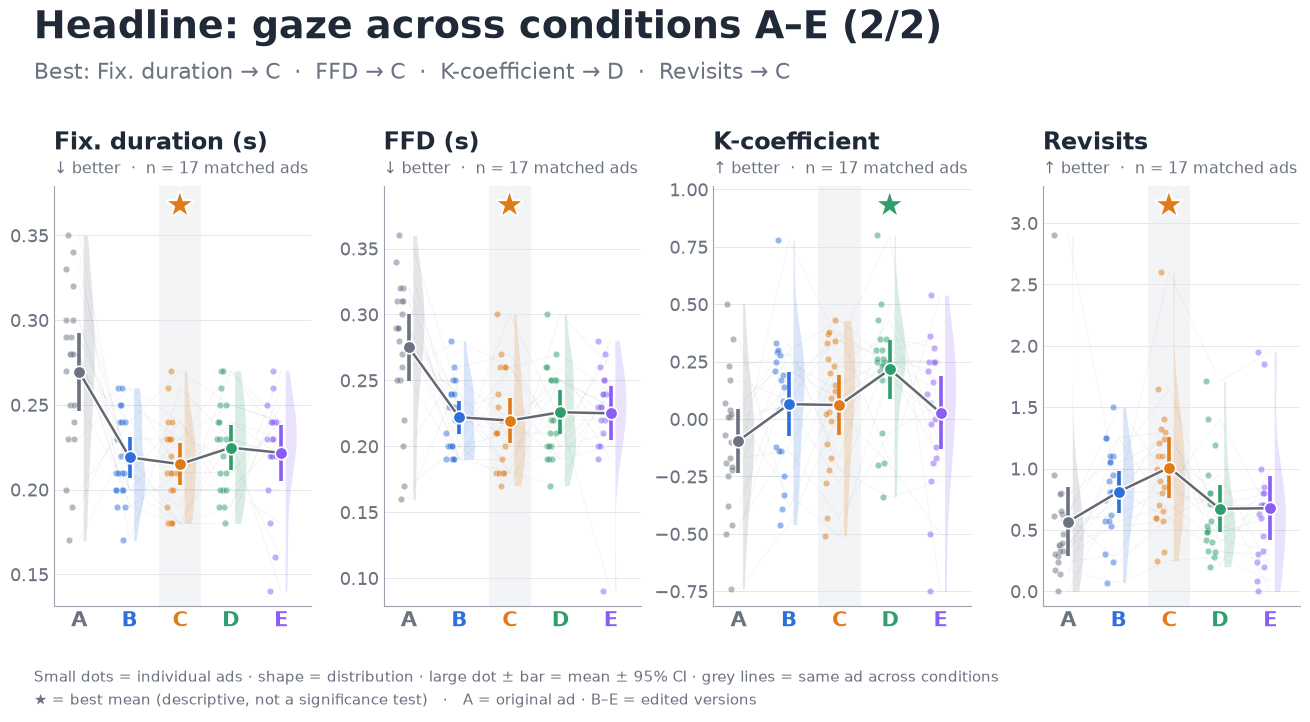

Saved: slides_suite\S04_raincloud_Headline_2.png (+ .svg)


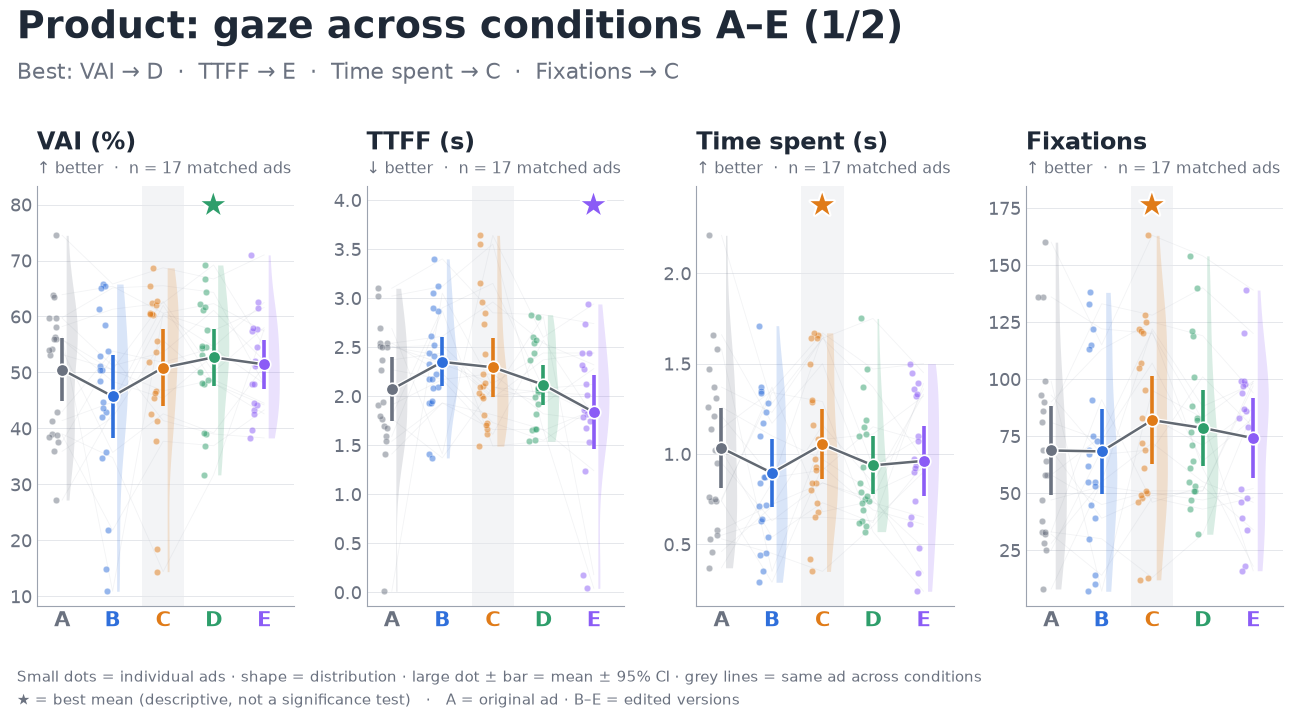

Saved: slides_suite\S04_raincloud_Product_1.png (+ .svg)


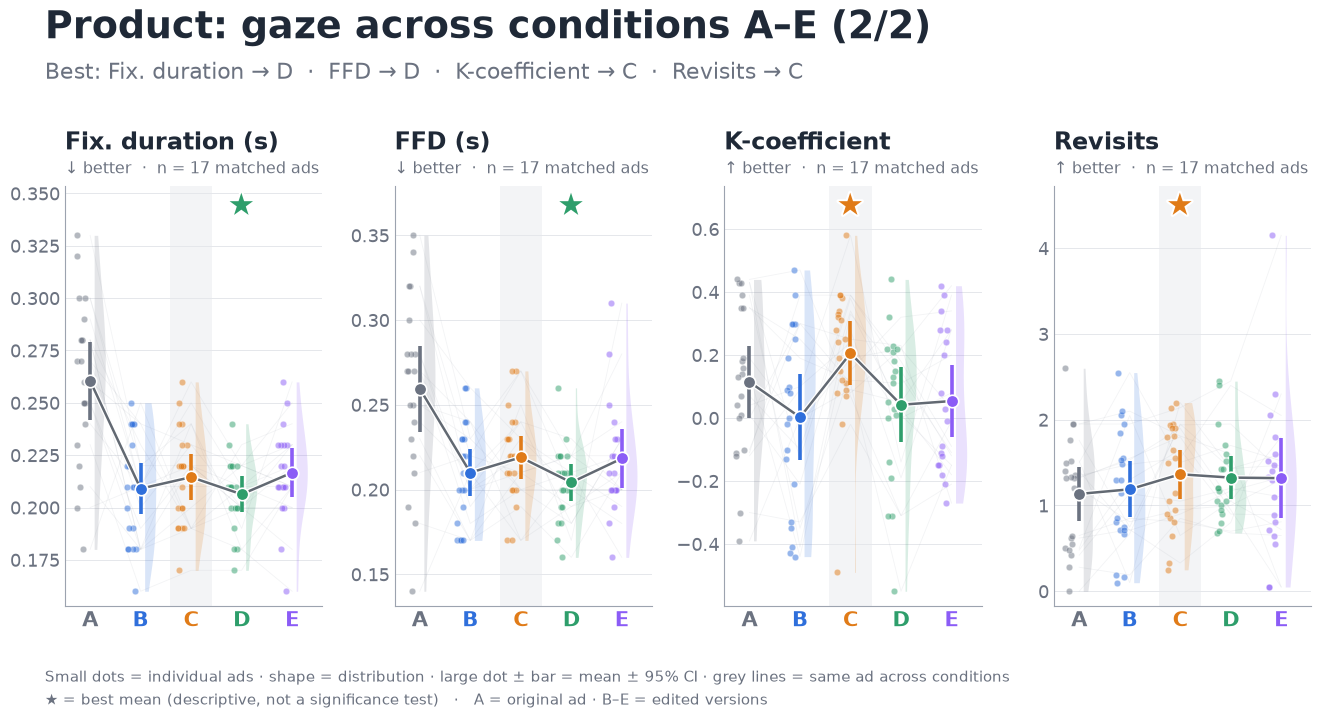

Saved: slides_suite\S04_raincloud_Product_2.png (+ .svg)


In [9]:
def draw_half_violin(ax, x, values, color, width=0.22, alpha=0.18):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 3 or np.std(vals) == 0:
        return
    kde = gaussian_kde(vals)
    yy = np.linspace(vals.min(), vals.max(), 160)
    dens = kde(yy)
    if dens.max() > 0:
        dens = dens / dens.max() * width
    ax.fill_betweenx(yy, x, x + dens, color=color, alpha=alpha, linewidth=0, zorder=1)


def draw_raincloud_panel(ax, aoi, metric, panel_idx):
    focus = get_focus(aoi, metric)
    if focus.empty:
        ax.set_visible(False)
        return None

    summary = get_summary(focus)
    pivot = get_pivot(focus)
    xs = {c: i for i, c in enumerate(CONDITION_ORDER)}

    if HIGHLIGHT_CONDITION in xs:
        ax.axvspan(xs[HIGHLIGHT_CONDITION] - 0.42, xs[HIGHLIGHT_CONDITION] + 0.42,
                   color="#F3F4F6", zorder=0, lw=0)

    complete = pivot.dropna()
    for _, row in complete.iterrows():
        ax.plot(np.arange(len(CONDITION_ORDER)), row[CONDITION_ORDER].astype(float).values,
                color="#9CA3AF", linewidth=0.6, alpha=0.12, zorder=1)

    rng = np.random.default_rng(RANDOM_SEED + panel_idx)
    for cond in CONDITION_ORDER:
        vals = focus.loc[focus["condition"] == cond, "value"].dropna().astype(float).values
        x = xs[cond]
        draw_half_violin(ax, x + 0.08, vals, CONDITION_COLORS[cond])
        jitter = rng.uniform(-0.28, -0.08, size=len(vals))
        ax.scatter(x + jitter, vals, s=22, alpha=0.5, color=CONDITION_COLORS[cond],
                   edgecolors="white", linewidths=0.4, zorder=3)

    ax.plot(np.arange(len(CONDITION_ORDER)), summary["mean"].values, color=TEXT,
            linewidth=1.8, alpha=0.7, zorder=4,
            path_effects=[pe.Stroke(linewidth=3.6, foreground="white"), pe.Normal()])

    for _, r in summary.iterrows():
        ax.errorbar(xs[r["condition"]], r["mean"], yerr=r["ci95"], fmt="o",
                    markersize=9, capsize=0, elinewidth=2.6,
                    color=CONDITION_COLORS[r["condition"]],
                    markeredgecolor="white", markeredgewidth=1.2, zorder=6)

    lo, hi = float(focus["value"].min()), float(focus["value"].max())
    rng_ = max(1e-6, hi - lo)
    ax.set_ylim(lo - 0.04 * rng_, hi + 0.14 * rng_)     # headroom for the star

    best_cond = get_best_condition(summary, metric)
    if best_cond is not None:
        # star at the top of the panel above the winning condition: never hidden by data
        draw_star(ax, xs[best_cond], hi + 0.08 * rng_, CONDITION_COLORS[best_cond], size=22)

    arrow = "↓ better" if BEST_RULES.get(metric) == "min" else "↑ better"
    ax.set_title(metric, loc="left", fontsize=17, fontweight="bold", color=TEXT, pad=26)
    ax.text(0, 1.02, f"{arrow}  ·  n = {len(complete)} matched ads",
            transform=ax.transAxes, fontsize=11.5, color=MUTED, va="bottom")

    ax.set_xlim(-0.5, len(CONDITION_ORDER) - 0.4)
    ax.grid(axis="y", color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    style_axis(ax)
    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontweight="bold", fontsize=15)
    for lbl, c in zip(ax.get_xticklabels(), CONDITION_ORDER):
        lbl.set_color(CONDITION_COLORS[c])
    return best_cond


def create_raincloud_slides(aoi):
    chunks = [METRICS[i:i + METRICS_PER_RAIN_SLIDE]
              for i in range(0, len(METRICS), METRICS_PER_RAIN_SLIDE)]
    for part, metrics in enumerate(chunks, start=1):
        fig, axes = plt.subplots(1, len(metrics), figsize=SLIDE_SIZE)
        axes = np.atleast_1d(axes)
        fig.subplots_adjust(left=0.05, right=0.985, top=0.72, bottom=0.16, wspace=0.28)
        winners = []
        for k, (ax, metric) in enumerate(zip(axes, metrics)):
            b = draw_raincloud_panel(ax, aoi, metric, METRICS.index(metric))
            if b:
                winners.append(f"{short_metric(metric)} → {b}")
        suffix = f" ({part}/{len(chunks)})" if len(chunks) > 1 else ""
        add_title(fig, f"{aoi}: gaze across conditions A–E{suffix}",
                  "Best: " + "  ·  ".join(winners))
        add_footnote(fig, "Small dots = individual ads · shape = distribution · large dot ± bar = mean ± 95% CI · "
                          "grey lines = same ad across conditions\n★ = best mean (descriptive, not a significance test)   ·   "
                          + CONDITION_NOTE)
        save_slide(fig, f"S04_raincloud_{aoi}_{part}")


for aoi in AOIS:
    create_raincloud_slides(aoi)

## 9. Export tables used on the slides

In [10]:
effects.to_csv(SLIDE_DIR / "effects_dz_bootstrap.csv", index=False)
best.to_csv(SLIDE_DIR / "best_condition_per_cell.csv", index=False)
print("All files:")
for f in sorted(SLIDE_DIR.iterdir()):
    print("  ", f)

All files:
   slides_suite\best_condition_per_cell.csv
   slides_suite\effects_dz_bootstrap.csv
   slides_suite\S01_best_conditions.png
   slides_suite\S01_best_conditions.svg
   slides_suite\S02_effect_profiles.png
   slides_suite\S02_effect_profiles.svg
   slides_suite\S03a_effects_CTA.png
   slides_suite\S03a_effects_CTA.svg
   slides_suite\S03b_effects_Headline.png
   slides_suite\S03b_effects_Headline.svg
   slides_suite\S03c_effects_Product.png
   slides_suite\S03c_effects_Product.svg
   slides_suite\S04_raincloud_CTA_1.png
   slides_suite\S04_raincloud_CTA_1.svg
   slides_suite\S04_raincloud_CTA_2.png
   slides_suite\S04_raincloud_CTA_2.svg
   slides_suite\S04_raincloud_Headline_1.png
   slides_suite\S04_raincloud_Headline_1.svg
   slides_suite\S04_raincloud_Headline_2.png
   slides_suite\S04_raincloud_Headline_2.svg
   slides_suite\S04_raincloud_Product_1.png
   slides_suite\S04_raincloud_Product_1.svg
   slides_suite\S04_raincloud_Product_2.png
   slides_suite\S04_raincloud_Pr